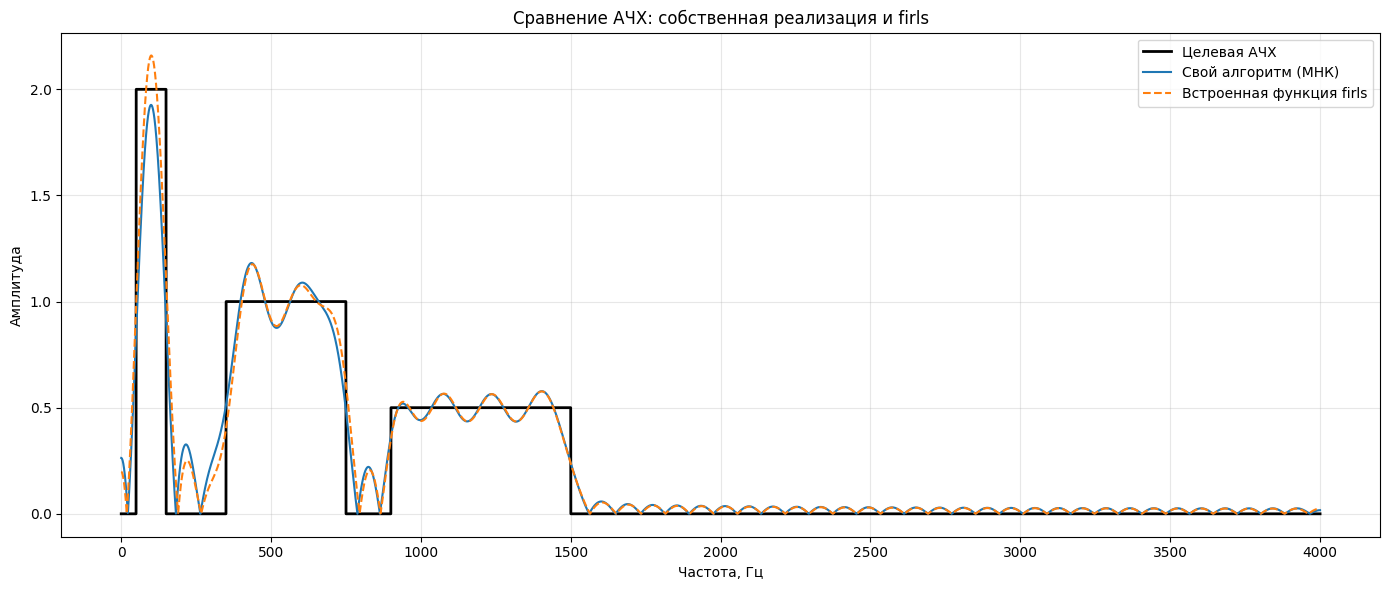

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firls, freqz

fs = 8000
L = 2
N = 101

def H_d(f):
    f = np.array(f)
    result = np.zeros_like(f, dtype=float)
    result = np.where((f >= 50) & (f <= 150), 2.0, result)
    result = np.where((f >= 350) & (f <= 750), 1.0, result)
    result = np.where((f >= 900) & (f <= 1500), 0.5, result)
    return result


M = (N - 1) // 2
omega = np.linspace(0, np.pi, N)
frequencies = omega * fs / (2 * np.pi)

A_resp = H_d(frequencies)

H_matrix = np.zeros((N, M + 1))
H_matrix[:, 0] = 1.0
for k in range(1, M + 1):
    H_matrix[:, k] = 2 * np.cos(k * omega)

y_vec = A_resp.reshape(-1, 1)

x_solution = np.linalg.inv(H_matrix.T @ H_matrix) @ H_matrix.T @ y_vec
x_solution = x_solution.flatten()

h = np.zeros(N)
h[M] = x_solution[0]
for k in range(1, M + 1):
    h[M - k] = x_solution[k]
    h[M + k] = x_solution[k]

f_plot = np.linspace(0, fs / 2, L * fs // 2)

w_impl, resp_impl = freqz(h, 1, f_plot, fs=fs)

bands = [0, 50, 50, 150, 150, 350, 350, 750, 750, 900, 900, 1500, 1500, fs // 2]
desired = [0, 0, 2, 2, 0, 0, 1, 1, 0, 0, 0.5, 0.5, 0, 0]
bandpass_lib = firls(N, bands, desired, fs=fs)
w_lib, resp_lib = freqz(bandpass_lib, 1, f_plot, fs=fs)


plt.figure(figsize=(14, 6))
plt.plot(f_plot, H_d(f_plot), label="Целевая АЧХ", color="black", linewidth=2)
plt.plot(w_impl, np.abs(resp_impl), label="Свой алгоритм (МНК)", linewidth=1.5)
plt.plot(w_lib, np.abs(resp_lib), label="Встроенная функция firls", linewidth=1.5, linestyle="--")
plt.xlabel("Частота, Гц")
plt.ylabel("Амплитуда")
plt.title("Сравнение АЧХ: собственная реализация и firls")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()